<a href="https://colab.research.google.com/github/20230583/wed_2026_bigdatacomputing/blob/main/%EB%B9%85%EB%8D%B0%EC%9D%B4%ED%84%B0_2%EC%B0%A8_%EA%B8%B0%EB%A7%90_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install streamlit pyngrok joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 58.1 MB/s eta 0:00:00


In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

import joblib
import os

# 데이터 로드
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url)

# 컬럼명 앞뒤 공백 제거
df.columns = df.columns.str.strip()

# 결측치 제거
df = df.dropna()

# 사용할 독립변수 선택
# Schooling은 과제 조건상 제외
features = ["Adult mortality", "BMI", "GDP", "Alcohol", "Polio"] # Changed 'Adult Mortality' to 'Adult mortality'

# 종속변수
target = "Life expectancy"

# 선택한 컬럼이 실제 데이터에 있는지 확인
required_cols = features + [target]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"다음 컬럼이 데이터에 없습니다: {missing_cols}")

X = df[features]
y = df[target]

print("사용한 특성:", features)
print("종속변수:", target)
print("전처리 후 데이터 크기:", df.shape)
df.head()

사용한 특성: ['Adult mortality', 'BMI', 'GDP', 'Alcohol', 'Polio']
종속변수: Life expectancy
전처리 후 데이터 크기: (1649, 22)


,Country,Year,Status,Life expectancy,Adult mortality,Infant deaths,Alcohol,Percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 years,Thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [15]:
# 전체 데이터를 80% train, 20% test로 분할
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 과대적합 관찰을 위해 train 데이터 중 50개만 무작위 샘플링
train_sample = X_train_full.copy()
train_sample[target] = y_train_full

train_sample_50 = train_sample.sample(n=50, random_state=42)

X_train = train_sample_50[features]
y_train = train_sample_50[target]

print("전체 Train 데이터 크기:", X_train_full.shape)
print("실제 학습에 사용한 Train 샘플 크기:", X_train.shape)
print("Test 데이터 크기:", X_test.shape)

전체 Train 데이터 크기: (1319, 5)
실제 학습에 사용한 Train 샘플 크기: (50, 5)
Test 데이터 크기: (330, 5)


In [16]:
# Model 1: Linear
# 1차 항 기반 선형 회귀 파이프라인
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=1, include_bias=False)),
    ("regressor", LinearRegression())
])

# Model 2: Poly
# 3차 다항 회귀, 규제 없음 → 과대적합 유도
poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("regressor", LinearRegression())
])

# Model 3: Ridge
# 3차 다항 회귀 + 릿지 규제
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("regressor", Ridge(alpha=1.0))
])

models = {
    "Linear": linear_model,
    "Poly": poly_model,
    "Ridge": ridge_model
}

# 모델 학습
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} 모델 학습 완료")

# 모델 저장
joblib.dump(linear_model, "linear_model.pkl")
joblib.dump(poly_model, "poly_model.pkl")
joblib.dump(ridge_model, "ridge_model.pkl")

# 앱에서 사용할 데이터와 특성 정보 저장
df.to_csv("life_expectancy_clean.csv", index=False)
joblib.dump(features, "features.pkl")

print("모델 및 파일 저장 완료")
print(os.listdir())

Linear 모델 학습 완료
Poly 모델 학습 완료
Ridge 모델 학습 완료
모델 및 파일 저장 완료
['.config', 'model_metrics.csv', 'life_expectancy_clean.csv', 'ridge_model.pkl', 'linear_model.pkl', 'features.pkl', 'poly_model.pkl', 'sample_data']


In [17]:
result_list = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    complexity = model.named_steps["poly"].n_output_features_

    result_list.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Complexity": complexity
    })

metrics_df = pd.DataFrame(result_list)

# 보기 좋게 반올림
metrics_df_rounded = metrics_df.copy()
metrics_df_rounded[["Train R2", "Test R2", "Train MSE", "Test MSE"]] = metrics_df_rounded[
    ["Train R2", "Test R2", "Train MSE", "Test MSE"]
].round(4)

metrics_df_rounded.to_csv("model_metrics.csv", index=False)

metrics_df_rounded

,Model,Train R2,Test R2,Train MSE,Test MSE,Complexity
0,Linear,0.7337,0.5832,29.1993,29.6014,5
1,Poly,1.0000,-770.0744,0.0000,54763.6222,55
2,Ridge,0.9536,0.3643,5.0854,45.1486,55


In [18]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="WHO 기대수명 예측 서비스",
    page_icon="🌍",
    layout="wide"
)

# -----------------------------
# 파일 로드
# -----------------------------
@st.cache_resource
def load_models():
    models = {
        "Linear": joblib.load("linear_model.pkl"),
        "Poly": joblib.load("poly_model.pkl"),
        "Ridge": joblib.load("ridge_model.pkl")
    }
    return models

@st.cache_data
def load_data():
    df = pd.read_csv("life_expectancy_clean.csv")
    features = joblib.load("features.pkl")
    metrics_df = pd.read_csv("model_metrics.csv")
    return df, features, metrics_df

models = load_models()
df, features, metrics_df = load_data()

# -----------------------------
# 제목
# -----------------------------
st.title("WHO 기대수명 예측 웹 서비스")
st.write("""
이 웹 서비스는 WHO 기대수명 데이터를 기반으로 사용자가 입력한 여러 건강·경제 관련 특성을 이용해
기대수명(Life expectancy)을 예측합니다.

본 과제에서는 기존 실습 특성인 **Schooling**을 제외하고,
**Adult Mortality, BMI, GDP, Alcohol, Polio** 특성을 사용했습니다.
""")

st.divider()

# -----------------------------
# 사이드바 입력
# -----------------------------
st.sidebar.header("입력값 조절")

input_data = {}

for feature in features:
    min_value = float(df[feature].min())
    max_value = float(df[feature].max())
    median_value = float(df[feature].median())

    step_value = (max_value - min_value) / 100

    if step_value == 0:
        step_value = 1.0

    input_data[feature] = st.sidebar.slider(
        label=feature,
        min_value=min_value,
        max_value=max_value,
        value=median_value,
        step=step_value
    )

# -----------------------------
# 모델 선택
# -----------------------------
st.sidebar.header("모델 선택")

selected_model_name = st.sidebar.selectbox(
    "예측에 사용할 모델을 선택하세요",
    ["Linear", "Poly", "Ridge"]
)

selected_model = models[selected_model_name]

# -----------------------------
# 실시간 예측
# -----------------------------
input_df = pd.DataFrame([input_data])

prediction = selected_model.predict(input_df)[0]

st.subheader("실시간 기대수명 예측 결과")

st.markdown(
    f"""
    <div style="
        background-color:#f0f2f6;
        padding:30px;
        border-radius:15px;
        text-align:center;
        font-size:32px;
        font-weight:bold;">
        선택한 모델: {selected_model_name}<br>
        예측 기대수명: {prediction:.2f} 세
    </div>
    """,
    unsafe_allow_html=True
)

st.write("입력된 데이터")
st.dataframe(input_df)

st.divider()

# -----------------------------
# 모델 성능 비교 테이블
# -----------------------------
st.subheader("각 모델의 성능 비교")

st.write("""
아래 표는 3가지 모델의 훈련 데이터와 테스트 데이터 성능을 비교한 결과입니다.
Complexity는 PolynomialFeatures 적용 후 생성된 총 특성 개수를 의미합니다.
""")

st.dataframe(metrics_df, use_container_width=True)

# -----------------------------
# Test R2 Bar Chart
# -----------------------------
st.subheader("Test R² 점수 비교 그래프")

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(metrics_df["Model"], metrics_df["Test R2"])
ax.set_xlabel("Model")
ax.set_ylabel("Test R² Score")
ax.set_title("Comparison of Test R² Scores")
ax.axhline(0, linewidth=1)

st.pyplot(fig)

st.divider()

# -----------------------------
# 해석 문구
# -----------------------------
st.subheader("결과 해석")

st.write("""
- **Linear 모델**은 1차 항만 사용하므로 구조가 단순하고 과대적합 위험이 상대적으로 낮습니다.
- **Poly 모델**은 3차 다항 특성을 사용하여 복잡도가 크게 증가하므로, 훈련 데이터에 과도하게 맞춰질 수 있습니다.
- **Ridge 모델**은 3차 다항 회귀를 사용하지만, 릿지 규제(alpha=1.0)를 적용하여 과대적합을 완화합니다.
""")

Writing app.py


In [23]:
from pyngrok import ngrok
from getpass import getpass
import os
import time

# ngrok 인증 토큰 입력
# ngrok 사이트에서 발급받은 authtoken을 입력하면 됨
# 이전에 잘못된 토큰을 입력하셨습니다. 올바른 토큰을 입력해주세요.
NGROK_AUTH_TOKEN = getpass("ngrok authtoken 입력: ")

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 기존 ngrok 터널 종료
ngrok.kill()

# Streamlit 실행
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > streamlit.log 2>&1 &

# 실행 대기
time.sleep(5)

# ngrok 터널 생성
public_url = ngrok.connect(8501, "http")

print("Streamlit Public URL:")
print(public_url)

ngrok authtoken 입력: ··········
Streamlit Public URL:
NgrokTunnel: "https://yin-elevate-feminism.ngrok-free.dev" -> "http://localhost:8501"


In [20]:
import os

files = [
    "app.py",
    "linear_model.pkl",
    "poly_model.pkl",
    "ridge_model.pkl",
    "features.pkl",
    "model_metrics.csv",
    "life_expectancy_clean.csv"
]

for file in files:
    if os.path.exists(file):
        print(f"존재함: {file}")
    else:
        print(f"없음: {file}")

존재함: app.py
존재함: linear_model.pkl
존재함: poly_model.pkl
존재함: ridge_model.pkl
존재함: features.pkl
존재함: model_metrics.csv
존재함: life_expectancy_clean.csv


## 웹 서비스 실행 결과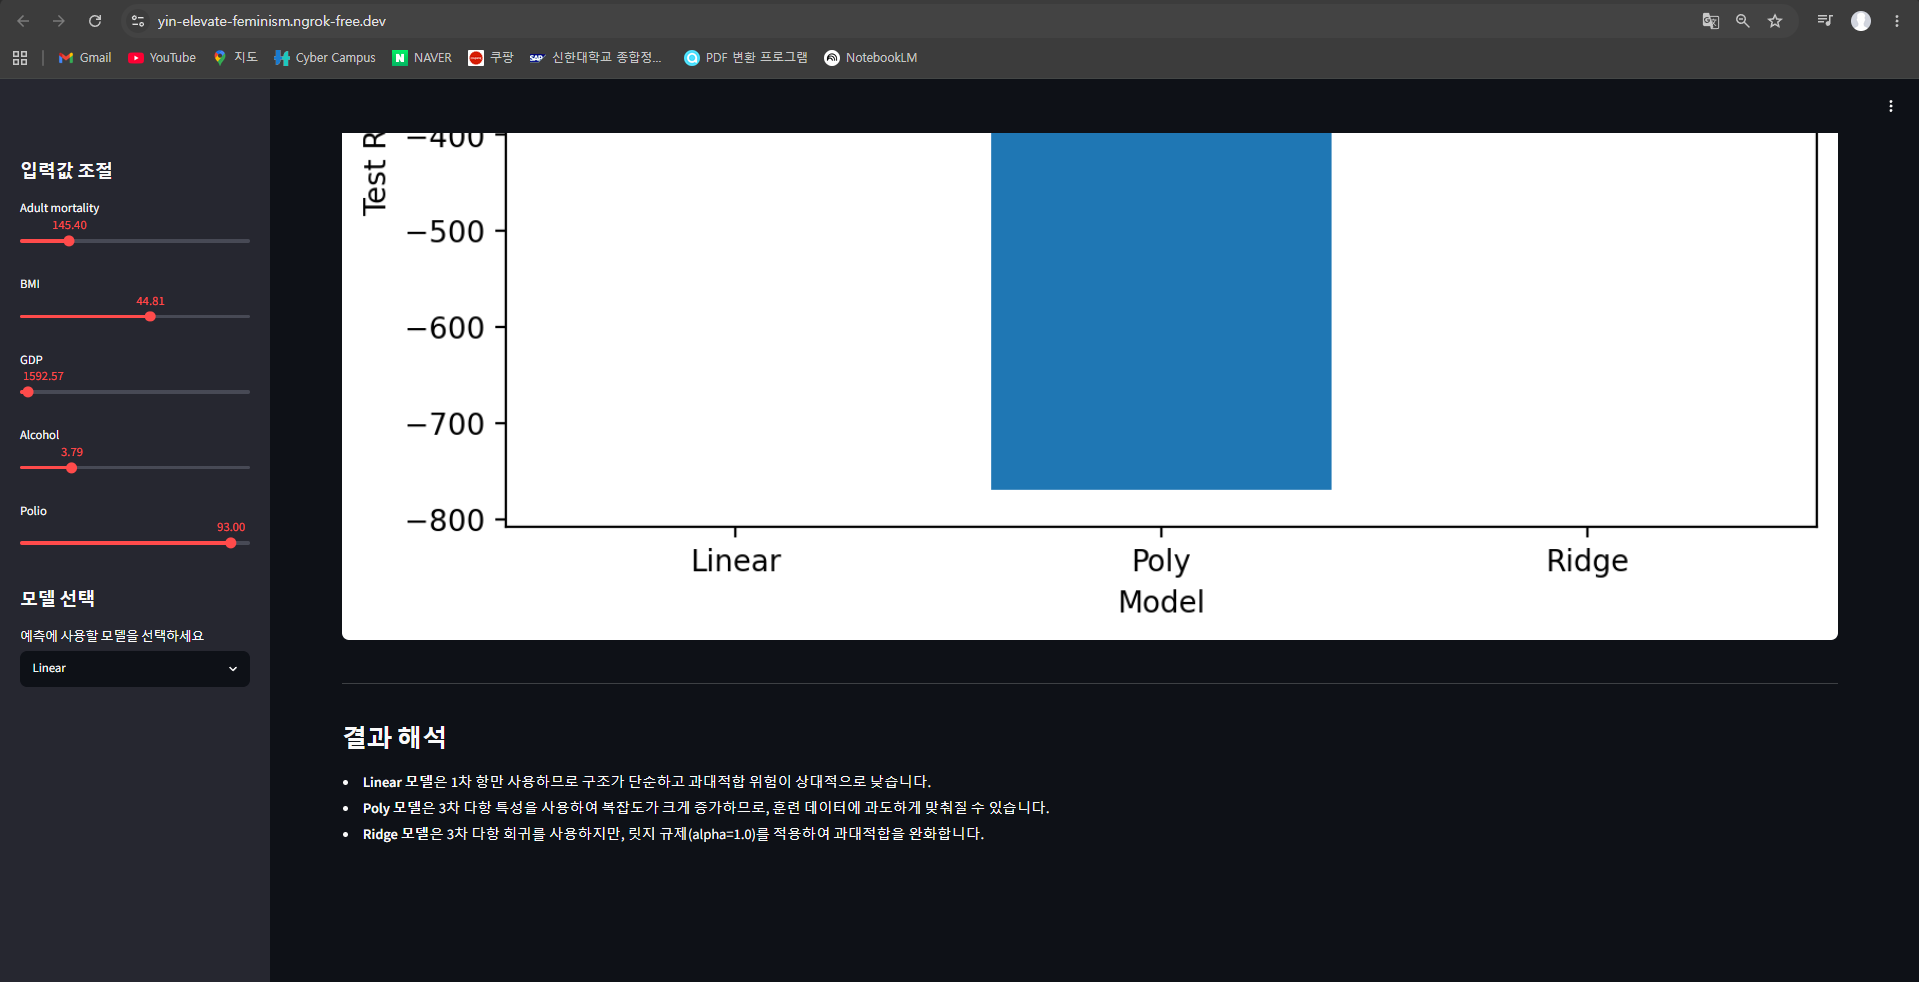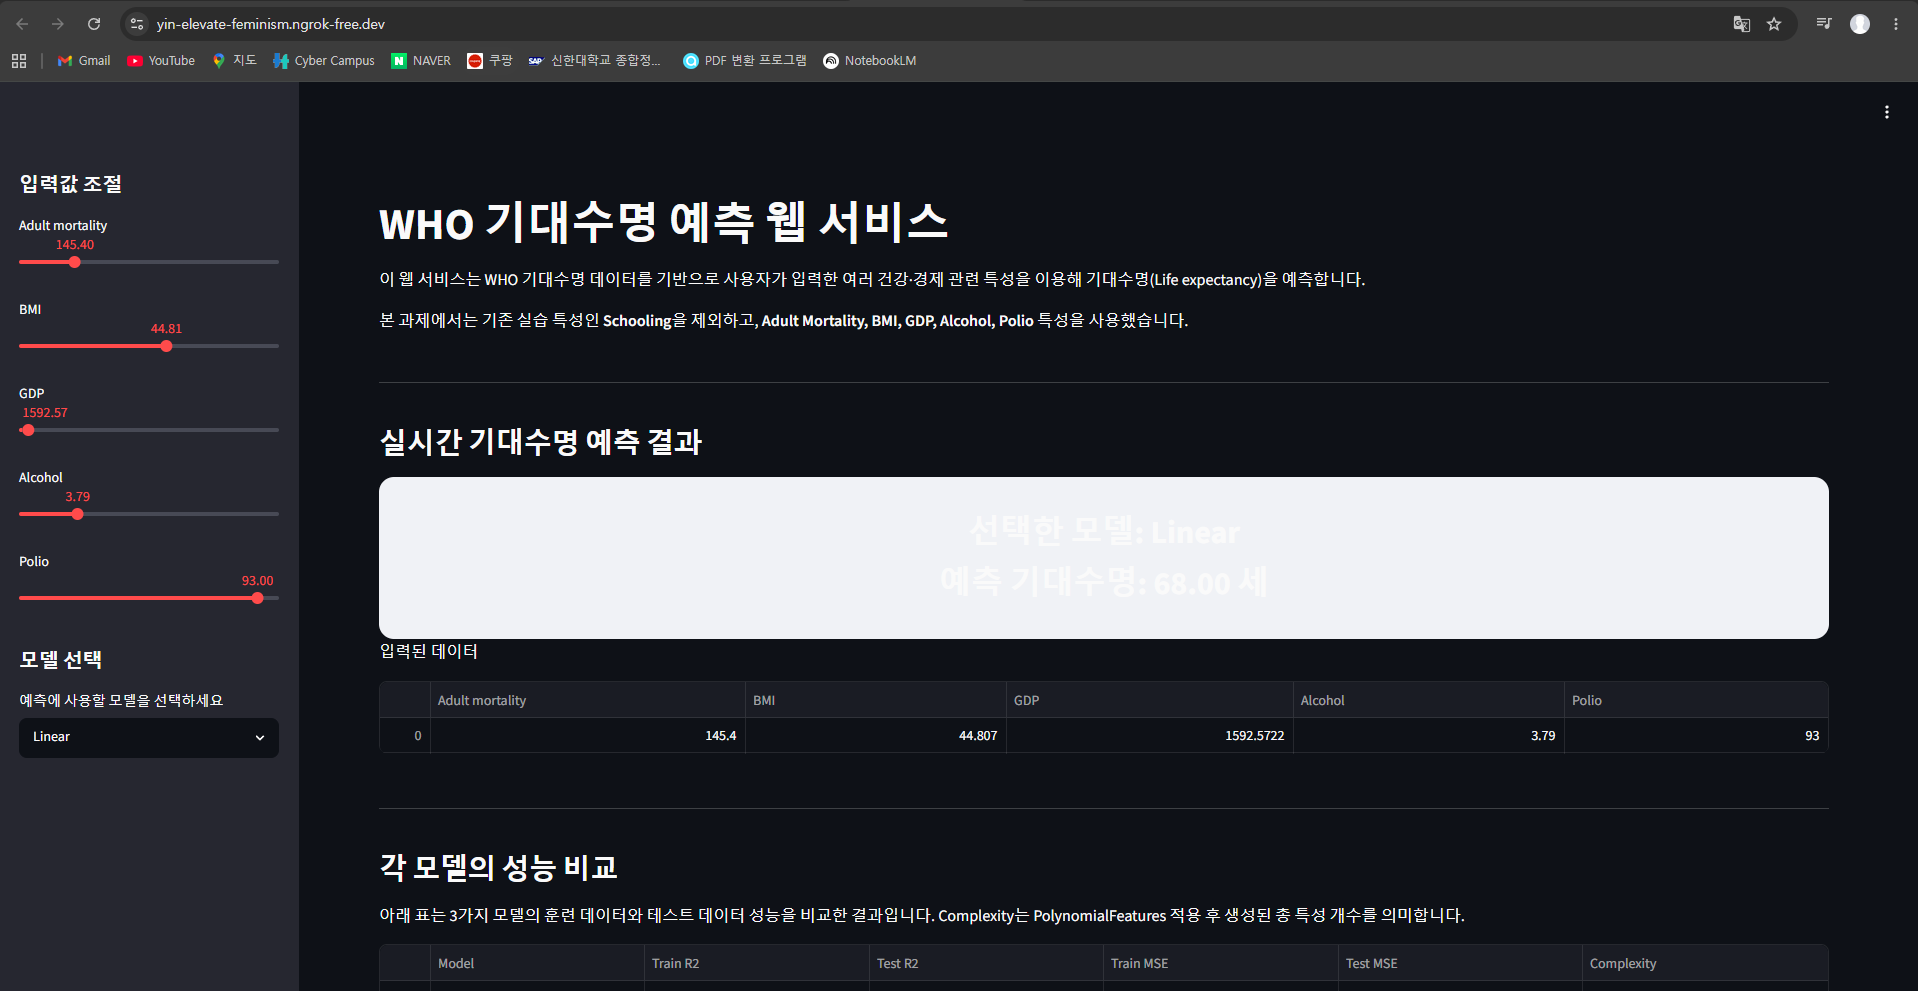